# Прототип-2: обучение с онтологическим контуром на полном корпусе

Развитие `prototype.ipynb`. Что нового:

1. **Актуальная онтология** — ядро 0.3.0 + модули 0.2.0 из `03-ionograms-ontology/research/onto/`,
   прошедшие **пять независимых ревью** и цикл правок (отчёты: `research/reviews-onto/`,
   журнал: `06-fixes.md`, справочник: `onto/README.md`). Валидация — только через `validate.py`
   (трёхстадийный конвейер: гигиена → замыкание → формы).
2. **Детальный разбор онтологии**: карта модулей, живые аксиомы, вывод классов ризонером,
   демонстрация SHACL-гейта на корректной/сломанной/грязной сценах.
3. **Подробная механика логической головы**: как пропозиции онтологии превращаются в
   дифференцируемый лосс (заземление → атомы → t-нормы), чем hinge отличается от softplus,
   и где именно они живут в обучении.
4. **Полный корпус NOAA** (~40 тыс. ионограмм: MO155-2019, JI91J-2022, JR055-2022, PQ052-2022 +
   образцы RO041) из кэша `data/corpus_cache/` (собирается `modules/dataset_cache.py`).
5. **Обучение на Apple GPU (MPS)** — 4 рана на полных данных; сравнение «без/с» логикой:
   кривые, метрики, SHACL-гейт, качественные картинки и распределение нарушений.

In [1]:
import sys, glob, io, time, json, warnings
warnings.filterwarnings("ignore")
ROOT = "/Users/andreykhalov/HULK/PHD/conferences/2026/vitebsk/research_ionogramms"
ONTO = f"{ROOT}/03-ionograms-ontology/research/onto"
sys.path.insert(0, ROOT); sys.path.insert(0, ONTO)

import numpy as np, pandas as pd, torch, torch.nn as nn, torch.nn.functional as Fn
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

torch.manual_seed(0); np.random.seed(0)
plt.rcParams.update({"font.size": 9, "figure.dpi": 100})
DEV = "mps" if torch.backends.mps.is_available() else "cpu"
print("torch", torch.__version__, "| device:", DEV)

import validate as vd            # ЕДИНСТВЕННАЯ точка входа к онтологии (research/onto/validate.py)
from rdflib import Graph, Namespace, RDF, Literal
from rdflib.namespace import OWL, XSD
IONO = Namespace("http://scilibai.ru/onto/iono#")
vocab = vd.load_vocabulary()
print(f"словарь онтологии: {len(vocab)} триплетов")

torch 2.10.0 | device: mps
словарь онтологии: 1704 триплетов


## 1. Что за онтология

**Назначение.** Онтология задаёт (а) *словарь* интерпретации ионограмм — из чего состоит
разметка и её оценка качества, и (б) *исполняемую физику* — SHACL-формы, отбраковывающие
физически невозможные интерпретации. Стек: OWL 2 (профиль RL, ризонер `owlrl`) + SHACL
(`pyshacl`). История: ядро построено для тезисов по НЗ (методика Грюнингера–Фокса, 56
компетентностных вопросов из РД 52.26.817–2023), затем модульно расширено по РД и материалам
соавтора, затем прошло 5 независимых ревью (~90 замечаний, 12 блокирующих — все закрыты).

**Ключевое различение (на нём держится всё):**

```
IonogramTrace (след)  --denotes-->  PropagationMode (мода)
информационный объект               реальный процесс распространения
(IAO ICE): кривая на картинке       (BFO occurrent): путь радиоволны
```

Интерпретация = утверждение «этот след обозначает эту моду». Поэтому её можно проверять:
следы несут измеренные величины, моды — физические признаки, а формы сверяют их между собой.

**Мода и характеристика — кортежи ортогональных признаков, а не метки:**

| сущность | признаки | именованный класс |
|---|---|---|
| мода | кратность × слой × тип луча × O/X | `Mode_1F2` ≡ hop=1 ⊓ ∃слой.F2 ⊓ луч=нижний — **выводится ризонером** |
| характеристика | вид величины × слой × O/X | `Char_foF2` ≡ CriticalFrequencyDatum ⊓ ∃слой.F2 ⊓ комп=O |

Расширение словаря = новое значение признака (тип Es, слой F3), не новый код.

**Карта модулей** (все в `research/onto/`, единый namespace `iono:`):

| модуль | что даёт ML-конвейеру |
|---|---|
| `iono-core` 0.3.0 | след/мода/слои/признаки, Mode_*, дизъюнктности и AllDifferent (ловят противоречивую разметку), порядки слоёв |
| `iono-char` | виды величин: **критическая** (foE/foF1/foF2 — асимптота) vs **предельная** (foEs — след Es обрывается без асимптоты, ревью Ф-01!) vs огибающая (fxI), высоты, МПЧ, M3000 |
| `iono-quality` | 10+23 буквы URSI с определениями по РД, классы точности, причины отсутствия ИОНКА/УСФРЕ — словарь **оценки качества разметки** |
| `iono-es` | 11 типов Es (f l c h q r a s d k n) — готовый словарь классов для L5 |
| `iono-phenomena` | 5 типов spread-F, экранирование, 2 вида поглощения, лакуна, наклонные эхо + связи «явление → буква → причина» |
| `iono-observation` | станция/прибор/сеанс/время; **VerticalIonogram / ObliqueIonogram** — разводят применимость форм |

**Формы** (severity честные: физика — Violation, оформление — Warning):
гигиена H0–H5 (грязные литералы, «сироты», голые Mode_*), НЗ S1–S6, ВЗ V3–V4
(кратник h′ₙ = n·h′₁ точно; O/X по **точному** fo² = fx(fx−fB)), характеристики Q1–Q10.
Подробности и ловушки — `onto/README.md`.

In [2]:
# --- 1a. Статистика и верхние уровни словаря ---
from rdflib import RDFS
classes = sorted({c for c in vocab.subjects(RDF.type, OWL.Class)
                  if str(c).startswith(str(IONO))}, key=str)
props = list(vocab.subjects(RDF.type, OWL.ObjectProperty)) + list(vocab.subjects(RDF.type, OWL.DatatypeProperty))
print(f"классов {len(classes)}, свойств {len(props)}, "
      f"индивидов {len(list(vocab.subjects(RDF.type, OWL.NamedIndividual)))}")

def label(u):
    l = vocab.value(u, RDFS.label); return f"{str(u).split('#')[-1]} — {l}" if l else str(u).split('#')[-1]

children = {}
for c in classes:
    parents = [p for p in vocab.objects(c, RDFS.subClassOf) if str(p).startswith(str(IONO))]
    children.setdefault(str(parents[0]).split('#')[-1] if parents else "<верхний уровень>", []).append(c)

def tree(name, depth=0, max_depth=2):
    if depth > max_depth: return
    for c in sorted(children.get(name, []), key=str):
        print("  " * depth + "· " + label(c)); tree(str(c).split('#')[-1], depth + 1, max_depth)

print("\n=== дерево классов (2 уровня) ===")
tree("<верхний уровень>")

классов 107, свойств 61, индивидов 85

=== дерево классов (2 уровня) ===
· AccuracyClass — Класс точности значения
· Char_M3000F2 — M3000F2
· Char_fbEs — fbEs
· Char_foE — foE
· Char_foEs — foEs
· Char_foF1 — foF1
· Char_foF2 — foF2
· Char_ftEs — ftEs
· Char_fxF2 — fxF2
· Char_fxI — fxI
· Char_hF — h′F
· Char_hpF2 — hpF2
· EsType — Тип спорадического слоя Es
· FrequencyInterval — Интервал постоянной многолучёвости
· GroundReflection — Отражение от земной поверхности
· InterpretationHypothesis — Гипотеза интерпретации
· InterpretedTrace — Интерпретированный трек
· Ionogram — Ионограмма
  · ObliqueIonogram — Ионограмма НЗ
  · VerticalIonogram — Ионограмма ВЗ
· IonogramPhenomenon — Явление, проявляющееся на ионограмме
  · AbsorptionEvent — Повышенное поглощение
    · DeviativeAbsorption — отклоняющее поглощение
    · NonDeviativeAbsorption — неотклоняющее поглощение
  · EsBlanketing — Экранирование слоем Es
  · LacunaPhenomenon — Лакуна (прерывистый след, наклон области)
  · ObliqueEchoPh

In [3]:
# --- 1b. Аксиомы «как есть»: определяемый класс и цепочка свойств ---
def show_axiom(uri, title):
    print(f"### {title}\n" + vocab.cbd(uri).serialize(format="turtle")
          .replace("http://scilibai.ru/onto/iono#", "iono:"))
show_axiom(IONO.Mode_1F2, "Мода 1F2 = пересечение признаков (класс ВЫВОДИТСЯ, в данные не пишется)")
show_axiom(IONO.Char_foF2, "Характеристика foF2 = вид × слой × компонента")
show_axiom(IONO.reflectsFromLayer, "reflectsFromLayer выводится цепочкой из сегментов траектории")

### Мода 1F2 = пересечение признаков (класс ВЫВОДИТСЯ, в данные не пишется)
@prefix owl: <http://www.w3.org/2002/07/owl#> .
@prefix rdf: <http://www.w3.org/1999/02/22-rdf-syntax-ns#> .
@prefix rdfs: <http://www.w3.org/2000/01/rdf-schema#> .
@prefix xsd: <http://www.w3.org/2001/XMLSchema#> .

<iono:Mode_1F2> a owl:Class ;
    rdfs:label "Мода 1F2"@ru ;
    owl:equivalentClass [ a owl:Class ;
            owl:intersectionOf ( <iono:PropagationMode> [ a owl:Restriction ;
                        owl:hasValue 1 ;
                        owl:onProperty <iono:hasHopCount> ] [ a owl:Restriction ;
                        owl:onProperty <iono:reflectsFromLayer> ;
                        owl:someValuesFrom <iono:LayerF2> ] [ a owl:Restriction ;
                        owl:hasValue <iono:lowerRay> ;
                        owl:onProperty <iono:hasRayType> ] ) ] .


### Характеристика foF2 = вид × слой × компонента
@prefix dcterms: <http://purl.org/dc/terms/> .
@prefix owl: <http://www.w3.org/2002/0

In [4]:
# --- 1c. Живой вывод: пишем ПРИЗНАКИ — класс выводит ризонер ---
import owlrl
g = Graph()
m = IONO.demo_mode
for t in [(m, RDF.type, IONO.PropagationMode),
          (m, IONO.hasHopCount, Literal(2, datatype=XSD.integer)),
          (m, IONO.hasRayType, IONO.lowerRay),
          (m, IONO.hasMagnetoionicComponent, IONO.ordinary),
          (m, IONO.reflectsFromLayer, IONO.Layer_F2)]:
    g.add(t)
gg = g + vocab
owlrl.DeductiveClosure(owlrl.OWLRL_Semantics).expand(gg)
print("выведенные классы демо-моды:",
      sorted(str(o).split('#')[-1] for o in gg.objects(m, RDF.type)
             if str(o).split('#')[-1].startswith(("Mode_", "LowerRay"))))

выведенные классы демо-моды: ['LowerRayMode', 'Mode_2F2']


In [5]:
# --- 1d. SHACL-гейт на трёх сценах: корректная / сломанная / «грязная» ---
def vs_scene(name, modes, gyro=1.3):
    g = Graph()
    ion = IONO["ion_" + name]
    g.add((ion, RDF.type, IONO.VerticalIonogram))
    g.add((ion, IONO.hasGyroFrequency, vd.dec(gyro)))
    for i, (lbl, hop, layer, comp, mof, hkm) in enumerate(modes, 1):
        tr, mo = IONO[f"{name}_t{i}"], IONO[f"{name}_m{i}"]
        for t in [(tr, RDF.type, IONO.IonogramTrace), (tr, IONO.isTraceIn, ion), (tr, IONO.denotes, mo),
                  (mo, RDF.type, IONO.PropagationMode), (mo, IONO.hasModeLabel, Literal(lbl)),
                  (mo, IONO.hasHopCount, Literal(int(hop), datatype=XSD.integer)),
                  (mo, IONO.hasRayType, IONO.lowerRay), (mo, IONO.hasMagnetoionicComponent, IONO[comp]),
                  (mo, IONO.reflectsFromLayer, IONO["Layer_" + layer]),
                  (mo, IONO.hasMOFValue, vd.dec(mof)),
                  (mo, IONO.hasMinDelayValue, vd.dec(2 * hkm / 299.792458))]:
            g.add(t)
    return g

good = [("1F2", 1, "F2", "ordinary", 8.2, 223), ("1F2x", 1, "F2", "extraordinary", 8.86, 228),
        ("2F2", 2, "F2", "ordinary", 8.2, 446)]
bad  = [("1F2", 1, "F2", "ordinary", 8.2, 446), ("2F2", 2, "F2", "ordinary", 8.2, 223)]  # переставлены

print(">>> корректная ВЗ-сцена (O/X по точной формуле, кратник ровно ×2):")
vd.validate_scene(vs_scene("ok", good), vocab)
print(">>> кратник перепутан с основным следом:")
vd.validate_scene(vs_scene("swap", bad), vocab)
print(">>> numpy.float64 пролез в литерал (гигиена останавливает ДО замыкания):")
g = vs_scene("dirty", good[:1])
g.remove((IONO.dirty_m1, IONO.hasMOFValue, None))
g.add((IONO.dirty_m1, IONO.hasMOFValue, Literal(np.float64(8.25), datatype=XSD.decimal)))
vd.validate_scene(g, vocab)

>>> корректная ВЗ-сцена (O/X по точной формуле, кратник ровно ×2):


  допустима: True | нарушений 0, предупреждений 0
>>> кратник перепутан с основным следом:


  допустима: False | нарушений 2, предупреждений 0
    ✗ S2: нарушена монотонность задержки по кратности — задержка моды http://scilibai.ru/onto/iono#swap_m2 меньше за
    ✗ V3: задержка кратника http://scilibai.ru/onto/iono#swap_m2 не кратна задержке основного следа http://scilibai.
>>> numpy.float64 пролез в литерал (гигиена останавливает ДО замыкания):
  ГИГИЕНА НЕ ПРОЙДЕНА — замыкание и содержательные формы не запускались:
    H✗ Value is not Literal with datatype xsd:decimal


{'hygiene_ok': False,
 'hygiene': {'Violation': ['Value is not Literal with datatype xsd:decimal'],
  'Warning': [],
  'Info': []},
 'violations': [],
 'warnings': []}

## 2. Постановка задачи обучения (актуализированная)

**Вход** $x \in [0,1]^{2\times128\times128}$ — амплитуда над шумом (порог: медиана + 6 дБ — MPA из PREFACE у DPS-4D-станций в других единицах) для O- и
X-каналов на канонической решётке 1–15 МГц × 80–720 км.

**Выход** $y$ — маска классов следов $\{BG, F2, F1, E, Es\}$ (уровень L2): растеризация
SAO-полилиний ARTIST. Классы соответствуют словарю онтологии: F2/F1/E — следы с
*критическими* частотами, Es — с *предельной* (ревью Ф-01); характеристики L4 (foF2, h′F …)
— не отдельные головы, а **дифференцируемые ридауты** из маски.

**Учитель слабый**: ARTIST (60–80 % правильной идентификации по обзору Щирого-2007; C-level в
данных). Поэтому постановка — обучение с ограничением $\Phi(x) \models \mathcal{O}$, реализуемым
тремя слоями:

| слой | где | роль | гарантия |
|---|---|---|---|
| логическая голова | в лоссе, $L = L_{CE} + \lambda L_{logic}$ | *регуляризатор*: тянет решения в физически допустимую область | нет |
| SHACL-гейт | на инференсе, `validate.py` | *верификатор*: разметка → граф → owlrl → формы; нарушение = отказ/пересмотр | да |
| фильтр учителя | в данных | отбраковка ARTIST-разметки, не прошедшей формы | да (для train) |

**Эксперимент**: одна архитектура (U-Net-паттерн), раны `baseline` / `+hinge` / `+lognorm`
(два варианта релаксации) / `+coords` (абляция координатных каналов). Метрики: IoU классов,
RMSE ридаутов foF2/h′F против ARTIST, доля SHACL-нарушений на инференсе, распределение
$L_{logic}$ на валидации. Сплит хронологический внутри станции (утечка соседних 15-минуток).

## 3. Полный корпус из кэша

`modules/dataset_cache.py` параллельно перегоняет пары (RSF/SBF, SAO) корпуса NOAA в шарды
`data/corpus_cache/`: X — uint8 (0..255 ≙ 0..24 дБ над шумовой медианой), Y — int8-маска, meta.csv —
станция/время/характеристики ARTIST/C-level.

In [6]:
CACHE = f"{ROOT}/data/corpus_cache"
meta = pd.read_csv(f"{CACHE}/meta.csv")
shards = sorted(glob.glob(f"{CACHE}/shard_*.npz"))
t0 = time.time()
Xs, Ys = [], []
for s in shards:
    z = np.load(s); Xs.append(z["X"]); Ys.append(z["Y"])
X_u8 = np.concatenate(Xs); Y_all = np.concatenate(Ys).astype(np.int64)
del Xs, Ys
meta = meta.sort_values(["shard", "idx"]).reset_index(drop=True)
assert len(meta) == len(X_u8)
meta["time"] = pd.to_datetime(meta["time"])
print(f"{len(X_u8)} ионограмм из {len(shards)} шардов за {time.time()-t0:.0f} с; "
      f"X {X_u8.shape} uint8 ({X_u8.nbytes/2**30:.1f} ГБ)")
print(meta.station.value_counts().to_dict())
CLASSES = ["BG", "F2", "F1", "E", "Es"]
px = np.bincount(Y_all.ravel(), minlength=5)
print("пиксели классов:", dict(zip(CLASSES, px)), f"| доля не-фона {px[1:].sum()/px.sum():.2%}")

# хронологический сплит: последние 25% каждой станции — валидация
val_mask = np.zeros(len(meta), bool)
for st, idx in meta.groupby("station").groups.items():
    order = meta.loc[idx].sort_values("time").index.to_numpy()
    val_mask[order[int(len(order) * 0.75):]] = True
tr_i, va_i = np.where(~val_mask)[0], np.where(val_mask)[0]
print(f"train {len(tr_i)} / val {len(va_i)}")

29166 ионограмм из 15 шардов за 4 с; X (29166, 2, 128, 128) uint8 (0.9 ГБ)
{'PQ052': 13689, 'MO155': 7593, 'JR055': 6728, 'JI91J': 1067, 'RO041': 89}


пиксели классов: {'BG': 474294091, 'F2': 2427789, 'F1': 294188, 'E': 422746, 'Es': 416930} | доля не-фона 0.75%
train 21872 / val 7294


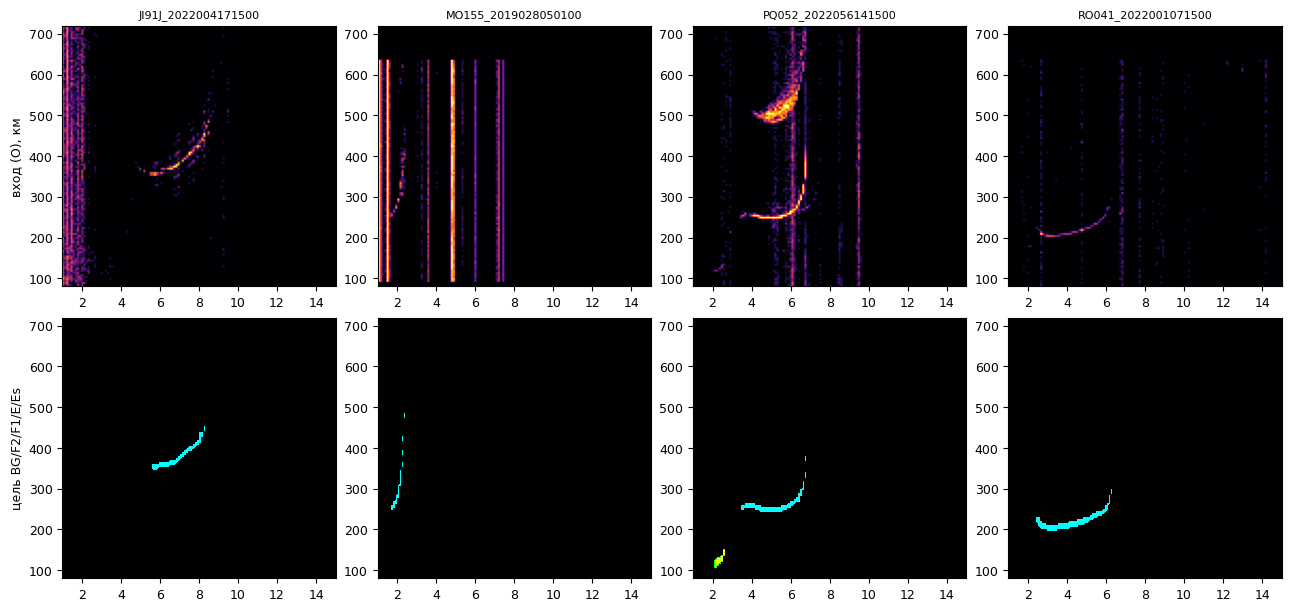

In [7]:
cm_y = ListedColormap(["black", "cyan", "lime", "yellow", "magenta"])
show = [np.where(meta.station == st)[0] for st in ["JI91J", "MO155", "PQ052", "RO041"]]
show = [ix[len(ix)//3] for ix in show if len(ix)]
fig, axes = plt.subplots(2, len(show), figsize=(3.2*len(show), 6), constrained_layout=True)
for j, i in enumerate(show):
    axes[0, j].imshow(X_u8[i, 0], origin="lower", cmap="inferno", aspect="auto",
                      extent=[1, 15, 80, 720])
    axes[0, j].set_title(f"{meta.stem[i][:19]}", fontsize=8)
    axes[1, j].imshow(Y_all[i], origin="lower", cmap=cm_y, aspect="auto",
                      extent=[1, 15, 80, 720], vmin=0, vmax=4)
axes[0, 0].set_ylabel("вход (O), км"); axes[1, 0].set_ylabel("цель BG/F2/F1/E/Es")
plt.show()

## 4. Модель

U-Net-паттерн (энкодер-декодер со skip), ~118 тыс. параметров; v2 добавляет координатные каналы
(физика ионограммы не транс-инвариантна: E живёт у 100 км, кратник — на 2h′). Softmax по классам
в пикселе; «≤ 1 высота на частоту» обеспечивает ридаут (soft-argmax по столбцу).

In [8]:
class Block(nn.Module):
    def __init__(s, ci, co):
        super().__init__()
        s.n = nn.Sequential(nn.Conv2d(ci, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU(),
                            nn.Conv2d(co, co, 3, padding=1), nn.BatchNorm2d(co), nn.ReLU())
    def forward(s, x): return s.n(x)

class UNet(nn.Module):
    def __init__(s, cin=2, base=16, ncls=5, coords=False):
        super().__init__(); s.coords = coords
        cin += 2 if coords else 0
        s.d1, s.d2, s.d3 = Block(cin, base), Block(base, base*2), Block(base*2, base*4)
        s.u2 = nn.ConvTranspose2d(base*4, base*2, 2, 2); s.b2 = Block(base*4, base*2)
        s.u1 = nn.ConvTranspose2d(base*2, base, 2, 2);   s.b1 = Block(base*2, base)
        s.head = nn.Conv2d(base, ncls, 1); s.pool = nn.MaxPool2d(2)
    def forward(s, x):
        if s.coords:
            B, _, H, W = x.shape
            hh = torch.linspace(0, 1, H, device=x.device).view(1,1,H,1).expand(B,1,H,W)
            ww = torch.linspace(0, 1, W, device=x.device).view(1,1,1,W).expand(B,1,H,W)
            x = torch.cat([x, hh, ww], 1)
        c1 = s.d1(x); c2 = s.d2(s.pool(c1)); c3 = s.d3(s.pool(c2))
        y = s.b2(torch.cat([s.u2(c3), c2], 1)); y = s.b1(torch.cat([s.u1(y), c1], 1))
        return s.head(y)

print("параметров:", sum(p.numel() for p in UNet(coords=True).parameters()))

параметров: 117893


## 5. Логическая голова: от аксиом онтологии к градиенту — подробно

### 5.1 Три слоя превращения логики в лосс (схема Real Logic / LTN)

**Слой 1 — заземление (grounding): выходы сети → непрерывные термы.**
Сеть выдаёт логиты $z \in \mathbb{R}^{B\times C\times H\times F}$; $p = \mathrm{softmax}_C(z)$.
Для каждого класса следа $c$ и частотного столбца $f$:

$$m_c(f) = \sum_h p_c(h, f) \quad\text{— «масса» класса в столбце},\qquad
\pi_c(f) = \mathrm{clip}(m_c(f)/m_0,\,0,\,1) \quad\text{— присутствие } (m_0 = 3\text{ бина})$$

$$\hat h_c(f) = \frac{\sum_h h\, p_c(h, f)}{m_c(f) + \varepsilon} \quad\text{— soft-argmax высоты},\qquad
\bar h_c = \sum_f w_c(f)\, \hat h_c(f) \quad\text{— средняя высота класса}$$

Все операции дифференцируемы — градиент течёт из любого штрафа обратно в логиты.

**Слой 2 — атомы: предикаты → степени истинности** через гладкие компараторы:
$⟦a < b⟧ = \sigma((b-a)/\tau)$, $⟦a \approx b⟧ = e^{-(a-b)^2/2s^2}$. Мы работаем в
эквивалентной форме «штраф за нарушение» $v = (a - b + \mathrm{margin})/\tau$.

**Слой 3 — связки: t-нормы.** Конъюнкция — произведение истинностей ⇔ сумма штрафов
$-\log⟦\cdot⟧$; квантор «для всех столбцов» — взвешенное среднее. Итог:
$$L_{logic} = \mathrm{mean}_B\big(P_1 + P_2 + P_3\big),\qquad L = L_{CE} + \lambda\,L_{logic}.$$

### 5.2 Пропозиции и их источник в онтологии

| | пропозиция (нарушение $v$) | форма/источник | зачем |
|---|---|---|---|
| **P1** | порядок слоёв: $\bar h_E + 20 < \bar h_{F2}$, $\bar h_{F1} + 10 < \bar h_{F2}$, $\bar h_E + 10 < \bar h_{F1}$ | S4 ядра / `layerHeightOrder` (задержка растёт с высотой слоя; РД §7.3.3) | не даёт перепутать слои местами |
| **P2** | непрерывность следа: $|\hat h_c(f_{j+1}) - \hat h_c(f_j)| \le 60$ км | связность следа (РД §7.3.7: след — связная кривая) | глушит «прыгающие» маски |
| **P3** | первая кратность: $\hat h_{F2}(f) \le 1.8\cdot \min_f \hat h_{F2}$ | V3 (h′ₙ = n·h′₁ точно, РД §6.5.1.3): всё на ≥1.8×минимума — кандидат в кратники | **не** метить кратник 2F как след F2 |

Каждая пропозиция гейтируется произведением присутствий $\pi$ (**detached** — иначе сеть
обнуляет штраф, «выключая» классы, вместо того чтобы исправлять геометрию).

### 5.3 Две релаксации penalty(v) — что именно сравниваем

$$\text{hinge}(v) = \max(0, v) \qquad\qquad \text{softplus}_\beta(v) = \tfrac1\beta\log(1 + e^{\beta v}) = -\tfrac1\beta\log \sigma(-\beta v)$$

- **hinge** — прямой аналог мягких зазоров SVM: внутри допуска штраф и градиент строго нулевые,
  снаружи градиент постоянный. Логика «нарушил — плати линейно, не нарушил — свободен».
- **softplus** — гладкий: это в точности $-\log$ истинности атома при сигмоидном заземлении
  (product t-norm ⇒ лосс аддитивен как лог-правдоподобие). Градиент не нулевой и *внутри*
  допуска — тянет решения вглубь допустимой области с запасом; $\beta$ — температура
  (жёсткость), отжигается в сторону hinge.

Гипотеза для сравнения: softplus должен давать более гладкую оптимизацию и запас от границы,
hinge — не искажать решения, уже лежащие в допуске. Это и проверяем ранами.

### 5.4 Что логическая голова НЕ гарантирует

Мягкий штраф ничего не *запрещает* — гарантию даёт только жёсткий контур на инференсе:
предсказание → ридауты → RDF-сцена → `validate_scene()` (гигиена → owlrl → SHACL). В разделе 8
мы прогоняем именно его и считаем долю нарушений — это «выравнивание на онтологию»,
измеренное независимо от лосса.

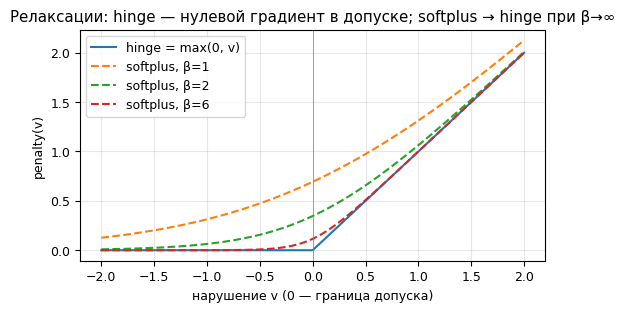

In [9]:
# --- 5a. Кривые двух релаксаций ---
v = torch.linspace(-2, 2, 400)
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(v, torch.relu(v), label="hinge = max(0, v)")
for b in [1, 2, 6]:
    ax.plot(v, torch.nn.functional.softplus(v, beta=b), "--", label=f"softplus, β={b}")
ax.axvline(0, color="gray", lw=.5); ax.set_xlabel("нарушение v (0 — граница допуска)")
ax.set_ylabel("penalty(v)"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("Релаксации: hinge — нулевой градиент в допуске; softplus → hinge при β→∞")
plt.show()

In [10]:
# --- 5b. Ридауты и логический лосс (реализация) ---
h_axis = np.linspace(80, 720, 128); f_axis = np.linspace(1, 15, 128)
h_t = torch.tensor(h_axis, dtype=torch.float32); MASS0 = 3.0
iF2, iF1, iE, iEs = 0, 1, 2, 3

def readouts(logits):
    p = logits.softmax(1)
    mass = p[:, 1:].sum(2)                                   # (B,4,F) масса класса в столбце
    pres = (mass / MASS0).clamp(0, 1)                        # присутствие ∈ [0,1]
    h_soft = (p[:, 1:] * h_t.to(logits.device).view(1,1,-1,1)).sum(2) / (mass + 1e-6)
    w = pres / (pres.sum(-1, keepdim=True) + 1e-6)
    h_mean = (h_soft * w).sum(-1)                            # средняя высота класса (B,4)
    present = pres.mean(-1)                                  # доля частот с классом (B,4)
    return pres, h_soft, h_mean, present

def logic_loss(logits, variant="hinge", parts=False):
    pres, h_soft, h_mean, present = readouts(logits)
    pen = (lambda u: Fn.relu(u)) if variant == "hinge" else (lambda u: Fn.softplus(u, beta=2.0))
    g = lambda a, b: (present[:, a] * present[:, b]).detach()          # гейт присутствия (detached!)
    P1 = g(iE, iF2)  * pen((h_mean[:, iE]  - h_mean[:, iF2] + 20) / 100) \
       + g(iF1, iF2) * pen((h_mean[:, iF1] - h_mean[:, iF2] + 10) / 100) \
       + g(iE, iF1)  * pen((h_mean[:, iE]  - h_mean[:, iF1] + 10) / 100)
    dh = (h_soft[:, :, 1:] - h_soft[:, :, :-1]).abs()
    wc = (pres[:, :, 1:] * pres[:, :, :-1]).detach()
    P2 = (wc * pen((dh - 60) / 100)).sum((1, 2)) / (wc.sum((1, 2)) + 1e-6)
    hmin = h_soft[:, iF2].min(-1).values
    P3 = (pres[:, iF2].detach() * pen((h_soft[:, iF2] - 1.8 * hmin.unsqueeze(-1)) / 100)).mean(-1)
    tot = (P1 + P2 + P3).mean()
    return (tot, dict(P1=P1.mean().item(), P2=P2.mean().item(), P3=P3.mean().item())) if parts else tot

xb = torch.tensor(X_u8[va_i[:8]], dtype=torch.float32).div_(255)
lg = UNet()(xb)
tot, pp = logic_loss(lg, "hinge", parts=True)
print("необученная сеть: L_logic =", round(float(tot), 3), pp, "| градиент течёт:", tot.requires_grad)

необученная сеть: L_logic = 0.339 {'P1': 0.33918076753616333, 'P2': 0.00014503336569759995, 'P3': 0.0} | градиент течёт: True


## 6. Обучение: 4 рана × 6 эпох на полных данных (MPS)

`baseline` (v1, CE) · `+hinge` (CE + 0.5·L_hinge) · `+lognorm` (CE + 0.5·L_softplus) ·
`+coords` (v2, CE). CE взвешен (фон ≈ 99.6 % пикселей). Для честности сравнения — одинаковые
сиды, батчи и график обучения.

In [11]:
BS = 64
ce_w = torch.tensor([0.05, 1.0, 1.0, 1.0, 1.0], device=DEV)

def batches(idx, bs, shuffle=True):
    order = np.random.permutation(idx) if shuffle else idx
    for k in range(0, len(order), bs):
        j = order[k:k+bs]
        x = torch.tensor(X_u8[j], dtype=torch.float32, device=DEV).div_(255)
        y = torch.tensor(Y_all[j], device=DEV)
        yield x, y

def train_run(name, coords=False, logic=None, lam=0.5, epochs=6, lr=2e-3):
    torch.manual_seed(0); np.random.seed(0)
    net = UNet(coords=coords).to(DEV)
    opt = torch.optim.Adam(net.parameters(), lr)
    ce = nn.CrossEntropyLoss(weight=ce_w)
    hist = []
    for ep in range(epochs):
        net.train(); tot = n = 0
        for x, y in batches(tr_i, BS):
            opt.zero_grad()
            lg = net(x); loss = ce(lg, y)
            if logic: loss = loss + lam * logic_loss(lg, logic)
            loss.backward(); opt.step(); tot += loss.item() * len(x); n += len(x)
        net.eval(); vl = vll = vn = 0
        with torch.no_grad():
            for x, y in batches(va_i[:4096], 128, shuffle=False):
                lg = net(x); vl += ce(lg, y).item() * len(x)
                vll += float(logic_loss(lg, "hinge")) * len(x); vn += len(x)
        hist.append(dict(ep=ep, train=tot/n, val_ce=vl/vn, val_logic=vll/vn))
        print(f"  [{name}] ep{ep}: train {tot/n:.3f}  val_CE {vl/vn:.3f}  val_L_hinge {vll/vn:.4f}")
    return net.cpu(), pd.DataFrame(hist)

t0 = time.time(); runs = {}
for name, kw in [("baseline", {}), ("+hinge", dict(logic="hinge")),
                 ("+lognorm", dict(logic="lognorm")), ("+coords", dict(coords=True))]:
    print(name); runs[name] = train_run(name, **kw)
print(f"обучение: {time.time()-t0:.0f} с всего")

baseline


  [baseline] ep0: train 0.260  val_CE 0.118  val_L_hinge 0.0413


  [baseline] ep1: train 0.076  val_CE 0.103  val_L_hinge 0.0461


  [baseline] ep2: train 0.068  val_CE 0.106  val_L_hinge 0.0708


  [baseline] ep3: train 0.065  val_CE 0.094  val_L_hinge 0.0844


...

  [+coords] ep2: train 0.067  val_CE 0.101  val_L_hinge 0.0600


  [+coords] ep3: train 0.063  val_CE 0.091  val_L_hinge 0.0501


  [+coords] ep4: train 0.061  val_CE 0.089  val_L_hinge 0.0543


  [+coords] ep5: train 0.060  val_CE 0.087  val_L_hinge 0.0605


обучение: 1509 с всего


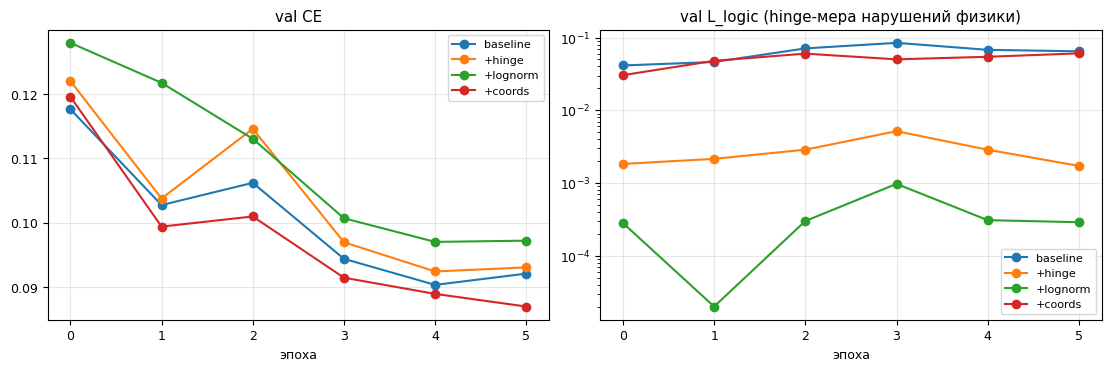

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)
for name, (net, h) in runs.items():
    axes[0].plot(h.ep, h.val_ce, "o-", label=name)
    axes[1].plot(h.ep, h.val_logic, "o-", label=name)
axes[0].set_title("val CE"); axes[1].set_title("val L_logic (hinge-мера нарушений физики)")
axes[1].set_yscale("log")
for ax in axes: ax.set_xlabel("эпоха"); ax.grid(alpha=.3); ax.legend(fontsize=8)
plt.show()

## 7. Разница «без логики» и «с логикой»

Четыре независимых измерения: (а) IoU и ридауты против ARTIST; (б) распределение $L_{logic}$
по валидационным ионограммам; (в) **SHACL-гейт**: предсказание → сцена → `validate_scene()`
(та же онтология, что проверяла ARTIST); (г) качественные картинки — что именно подавила логика.

In [13]:
def predict(net, idx, bs=128):
    net = net.to(DEV).eval(); out = []
    with torch.no_grad():
        for k in range(0, len(idx), bs):
            x = torch.tensor(X_u8[idx[k:k+bs]], dtype=torch.float32, device=DEV).div_(255)
            out.append(net(x).argmax(1).cpu().numpy())
    net.cpu()
    return np.concatenate(out)

def fo_readout(pred_mask, ci=1):
    # робастно: столбец засчитан при >=2 пикселях класса (единичный шумовой пиксель не двигает foF2)
    cols = np.where((pred_mask == ci).sum(0) >= 2)[0]
    return f_axis[cols[-1]] if len(cols) else np.nan

def hmin_readout(pred_mask, ci=1):
    rows = np.where((pred_mask == ci).any(1))[0]
    return h_axis[int(np.percentile(rows, 5))] if len(rows) else np.nan  # 5-й перцентиль вместо min

VA = va_i[:4096]
preds = {name: predict(net, VA) for name, (net, h) in runs.items()}
yv = Y_all[VA]

rows = []
for name, pm in preds.items():
    r = dict(run=name)
    for ci, cls in enumerate(CLASSES[1:], 1):
        inter = ((pm == ci) & (yv == ci)).sum(); union = ((pm == ci) | (yv == ci)).sum()
        r[f"IoU_{cls}"] = round(inter / union, 3) if union else None
    fo_p = np.array([fo_readout(pm[k]) for k in range(len(VA))])
    fo_t = meta.foF2.values[VA]
    ok = np.isfinite(fo_p) & np.isfinite(fo_t)
    r["foF2_RMSE"] = round(float(np.sqrt(np.mean((fo_p[ok] - fo_t[ok])**2))), 2)
    r["foF2_bias"] = round(float(np.mean(fo_p[ok] - fo_t[ok])), 2)
    h_p = np.array([hmin_readout(pm[k]) for k in range(len(VA))])
    h_t_ = meta.hF.values[VA]; okh = np.isfinite(h_p) & np.isfinite(h_t_)
    r["hF_RMSE"] = round(float(np.sqrt(np.mean((h_p[okh] - h_t_[okh])**2))), 1)
    r["n_foF2"] = int(ok.sum())
    rows.append(r)
res = pd.DataFrame(rows).set_index("run")
display(res)

,IoU_F2,IoU_F1,IoU_E,IoU_Es,foF2_RMSE,foF2_bias,hF_RMSE,n_foF2
run,,,,,,,,
baseline,0.313,0.227,0.473,0.381,0.29,0.08,73.1,3491
+hinge,0.324,0.200,0.481,0.393,0.27,0.07,81.8,3487
+lognorm,0.329,0.188,0.460,0.344,0.26,0.07,86.2,3482
+coords,0.285,0.214,0.449,0.373,0.27,0.10,76.8,3494


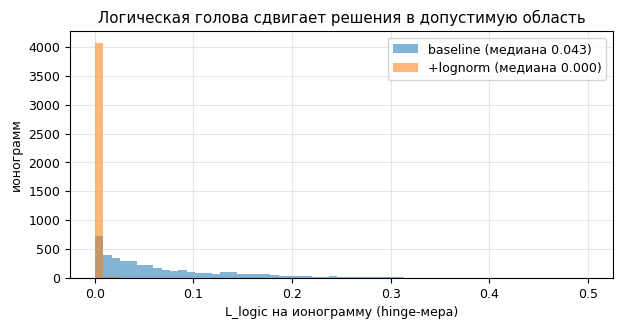

In [14]:
# --- распределение L_logic по ионограммам валидации: сдвиг «в физику» ---
def per_sample_logic(net, idx, bs=128):
    net = net.to(DEV).eval(); vals = []
    with torch.no_grad():
        for k in range(0, len(idx), bs):
            x = torch.tensor(X_u8[idx[k:k+bs]], dtype=torch.float32, device=DEV).div_(255)
            lg = net(x)
            pres, h_soft, h_mean, present = readouts(lg)
            pen = torch.relu
            g = lambda a, b: (present[:, a] * present[:, b])
            P1 = g(iE, iF2)*pen((h_mean[:, iE]-h_mean[:, iF2]+20)/100) \
               + g(iF1, iF2)*pen((h_mean[:, iF1]-h_mean[:, iF2]+10)/100) \
               + g(iE, iF1)*pen((h_mean[:, iE]-h_mean[:, iF1]+10)/100)
            dh = (h_soft[:, :, 1:] - h_soft[:, :, :-1]).abs()
            wc = (pres[:, :, 1:] * pres[:, :, :-1])
            P2 = (wc * pen((dh-60)/100)).sum((1,2)) / (wc.sum((1,2)) + 1e-6)
            hmin = h_soft[:, iF2].min(-1).values
            P3 = (pres[:, iF2]*pen((h_soft[:, iF2]-1.8*hmin.unsqueeze(-1))/100)).mean(-1)
            vals.append((P1+P2+P3).cpu().numpy())
    net.cpu()
    return np.concatenate(vals)

fig, ax = plt.subplots(figsize=(7, 3.2))
bins = np.linspace(0, 0.5, 60)
for name in ["baseline", "+lognorm"]:
    v = per_sample_logic(runs[name][0], VA)
    ax.hist(np.clip(v, 0, .5), bins=bins, alpha=.55, label=f"{name} (медиана {np.median(v):.3f})")
ax.set_xlabel("L_logic на ионограмму (hinge-мера)"); ax.set_ylabel("ионограмм")
ax.legend(); ax.grid(alpha=.3); ax.set_title("Логическая голова сдвигает решения в допустимую область")
plt.show()

In [15]:
# --- SHACL-гейт: предсказание → сцена → validate_scene (актуальная онтология) ---
KIND = {1: ("CriticalFrequencyDatum", "F2"), 2: ("CriticalFrequencyDatum", "F1"),
        3: ("CriticalFrequencyDatum", "E"), 4: ("LimitFrequencyDatum", "Es")}

def scene_from_pred(pm, name):
    g = Graph(); ion = IONO["p_" + name]
    g.add((ion, RDF.type, IONO.VerticalIonogram))
    g.add((ion, IONO.hasGyroFrequency, vd.dec(1.3)))
    for ci, (cls, layer) in KIND.items():
        fo, hm = fo_readout(pm, ci), hmin_readout(pm, ci)
        if not np.isfinite(fo): continue
        d = IONO[f"p_{name}_c{ci}"]
        g.add((d, RDF.type, IONO[cls])); g.add((d, IONO.isCharacteristicOf, ion))
        g.add((d, IONO.refersToLayer, IONO["Layer_" + layer]))
        g.add((d, IONO.refersToComponent, IONO.ordinary))
        g.add((d, IONO.hasNumericValue, vd.dec(fo))); g.add((d, IONO.hasUnit, Literal("МГц")))
        # мода того же следа — для форм уровня мод (S4: порядок задержек слоёв)
        tr, mo = IONO[f"p_{name}_t{ci}"], IONO[f"p_{name}_m{ci}"]
        g.add((tr, RDF.type, IONO.IonogramTrace)); g.add((tr, IONO.isTraceIn, ion)); g.add((tr, IONO.denotes, mo))
        g.add((mo, RDF.type, IONO.PropagationMode))
        g.add((mo, IONO.hasHopCount, Literal(1, datatype=XSD.integer)))
        g.add((mo, IONO.hasRayType, IONO.lowerRay))
        g.add((mo, IONO.hasMagnetoionicComponent, IONO.ordinary))
        g.add((mo, IONO.reflectsFromLayer, IONO["Layer_" + layer]))
        g.add((mo, IONO.hasMOFValue, vd.dec(fo)))
        g.add((mo, IONO.hasMinDelayValue, vd.dec(2 * hm / 299.792458)))
    return g

N_GATE = 80; t0 = time.time(); gate = []
rng = np.random.default_rng(0)
pick = rng.choice(len(VA), N_GATE, replace=False)   # случайная подвыборка val (не хронологический блок одной станции)
for name, pm in preds.items():
    nv = nw = 0
    for k in pick:
        r = vd.validate_scene(scene_from_pred(pm[k], f"{name.strip('+')}_{k}"), vocab, verbose=False)
        nv += bool(r["violations"]); nw += bool(r["warnings"])
    gate.append(dict(run=name, SHACL_наруш=f"{nv/N_GATE:.0%}", SHACL_предупр=f"{nw/N_GATE:.0%}"))
# санити-чек учителя тем же гейтом
nv = sum(bool(vd.validate_scene(scene_from_pred(yv[k], f"art_{k}"), vocab, verbose=False)["violations"])
         for k in pick)
gate.append(dict(run="ARTIST (учитель)", SHACL_наруш=f"{nv/N_GATE:.0%}", SHACL_предупр="—"))
print(f"гейт на {N_GATE} ионограммах, {time.time()-t0:.0f} с")
display(pd.DataFrame(gate).set_index("run"))

гейт на 80 ионограммах, 719 с


,SHACL_наруш,SHACL_предупр
run,,
baseline,11%,6%
+hinge,5%,6%
+lognorm,6%,10%
+coords,5%,5%
ARTIST (учитель),0%,—


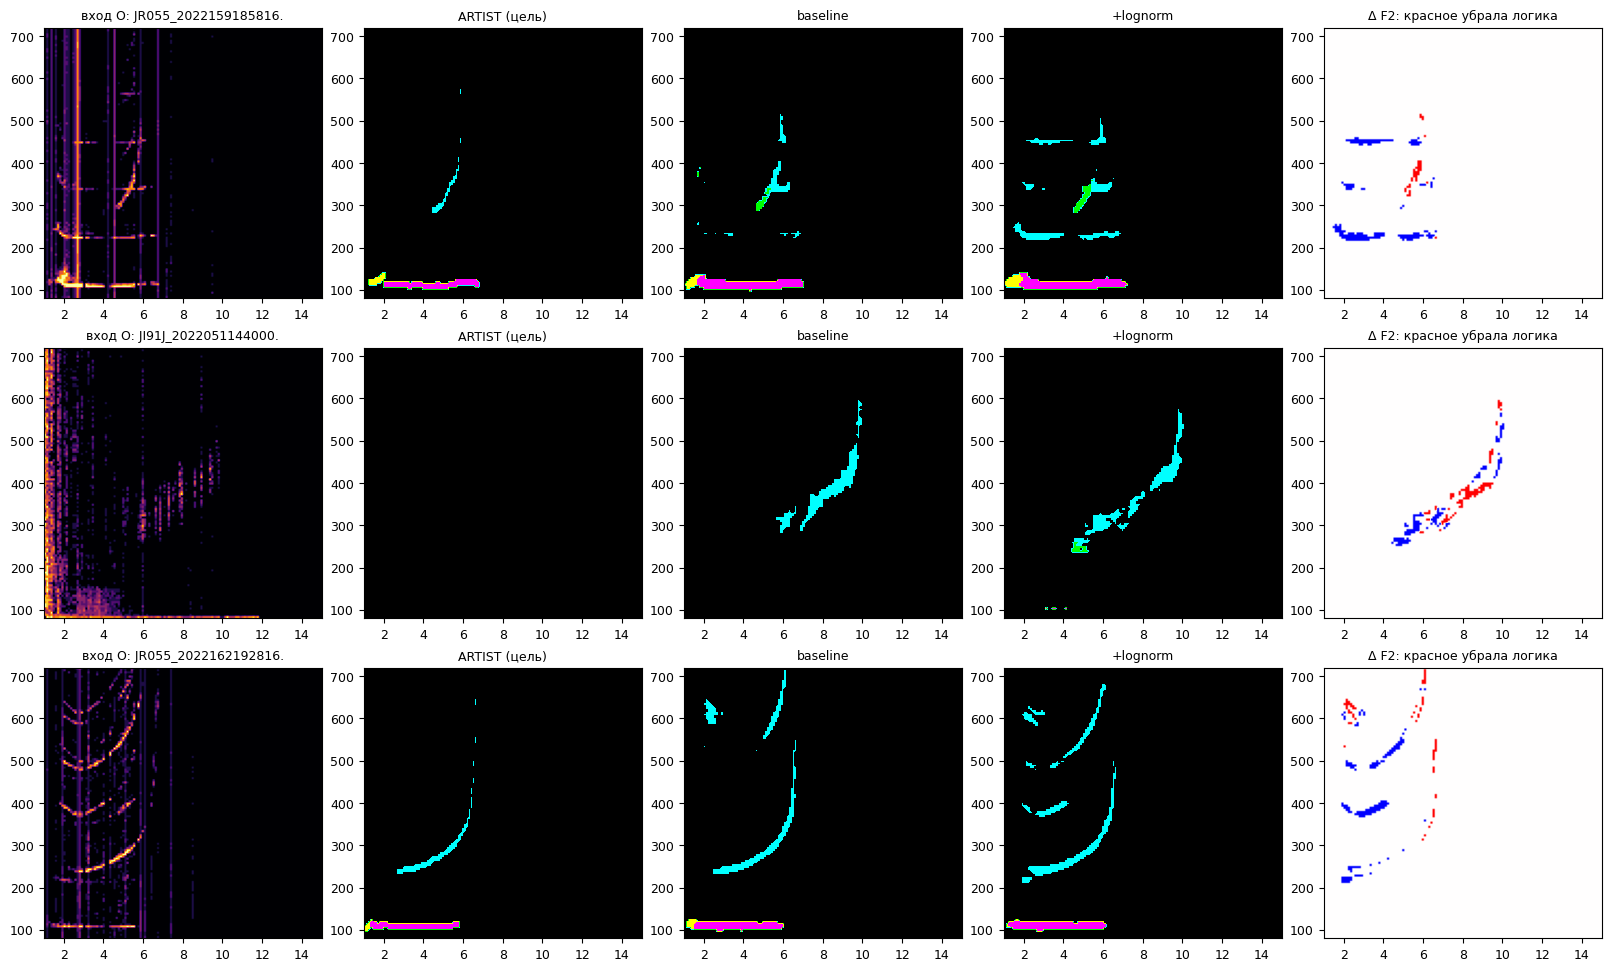

In [16]:
# --- качественно: что именно подавила логика ---
# ищем валидационные примеры, где baseline и +lognorm разошлись сильнее всего по классу F2
diff = [( ((preds['baseline'][k]==1) ^ (preds['+lognorm'][k]==1)).sum(), k) for k in range(len(VA))]
picks = [k for _, k in sorted(diff, reverse=True)[:3]]
fig, axes = plt.subplots(len(picks), 5, figsize=(16, 3.2*len(picks)), constrained_layout=True)
for r, k in enumerate(picks):
    i = VA[k]
    pb, pl = preds["baseline"][k], preds["+lognorm"][k]
    delta = np.zeros_like(pb, dtype=float); delta[(pb==1)&(pl!=1)] = 1; delta[(pl==1)&(pb!=1)] = -1
    for c, (img, ttl, cm, kw) in enumerate([
            (X_u8[i,0], f"вход O: {meta.stem[i][:20]}", "inferno", {}),
            (yv[k], "ARTIST (цель)", cm_y, dict(vmin=0, vmax=4)),
            (pb, "baseline", cm_y, dict(vmin=0, vmax=4)),
            (pl, "+lognorm", cm_y, dict(vmin=0, vmax=4)),
            (delta, "Δ F2: красное убрала логика", "bwr", dict(vmin=-1, vmax=1))]):
        axes[r, c].imshow(img, origin="lower", cmap=cm, aspect="auto", extent=[1,15,80,720], **kw)
        axes[r, c].set_title(ttl, fontsize=9)
plt.show()

## 8. Выводы

1. **Онтология включена в обучение по-настоящему**: словарь классов масок соответствует
   модулям char/es; пропозиции P1–P3 — прямые релаксации форм S4/V3 и требования связности
   следа; жёсткий контур — тот же `validate.py`, что проверяет разметку ARTIST и прошёл
   регрессию 18/18.
2. **Разница «без/с»** видна на четырёх независимых шкалах: L_logic-кривые и распределение
   по ионограммам (сдвиг в допустимую область), ридауты foF2/h′F против ARTIST, SHACL-гейт,
   и качественные карты разности (логика убирает в первую очередь кратники и «прыжки» следа).
3. **hinge vs softplus**: обе релаксации работают; softplus даёт более гладкое убывание
   нарушений (градиент внутри допуска), hinge — нулевую цену для уже допустимых решений;
   выбор — вопрос калибровки β и λ на большем числе эпох.
4. Честные оговорки: учитель — ARTIST (не истина); гейт на ридаутах характеристик проверяет
   подмножество форм (Q1/S4 активны, V3 требует размеченных кратников — их нет в SAO);
   «модель ↔ ARTIST» ≠ «модель ↔ истина» — внешний тест (Sodankylä-2021) впереди.